# Лабораторная работа №1. Линейная регрессия и факторный анализ

**Датасет:** Metro Interstate Traffic Volume (Интенсивность движения на автомагистралях между штатами)

**Цель работы:** изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качества.

---

## Постановка задачи

1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).
2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.
3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).
4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчёт VIF-коэффициента).
5. Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная — категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: **RMSE** (Root Mean Square Error), **R²** (коэффициент детерминации) и **MAPE** (Mean Absolute Percentage Error).
6. Построить график остатков моделей (добавить горизонтальную линию на уровне 0) и исследовать структуру остатков на предмет гомоскедастичности или гетероскедастичности.
7. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (**PCA**). Перед проведением PCA провести стандартизацию данных.
8. Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

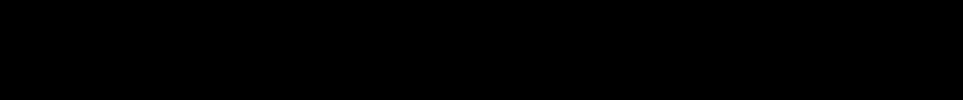

In [182]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit, cross_val_score
)
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_percentage_error
)
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA


Подключаем необходимые для работы библиотеки.

In [183]:
TARGET = 'traffic_volume'
dataset = fetch_ucirepo(id=492)
df = dataset.data.features.copy()
df[TARGET] = dataset.data.targets[TARGET]
cols_to_drop = ["weather_description", "rain_1h", "snow_1h"]
df = df.drop(columns=cols_to_drop, errors="ignore")
df = df.head(600).reset_index(drop=True)
print("Размер датасета (строк, столбцов):", df.shape)
df.head()


Размер датасета (строк, столбцов): (600, 6)


,holiday,temp,clouds_all,weather_main,date_time,traffic_volume
0,NaN,288.28,40,Clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,75,Clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,90,Clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,90,Clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,75,Clouds,2012-10-02 13:00:00,4918


## 1. Описание датасета

Датасет **Metro Interstate Traffic Volume**  содержит **6 переменных**: 5 независимых признаков и одну целевую переменную `traffic_volume` — значение трафика.

| Переменная | Описание | Тип                                         |
| --- | --- |---------------------------------------------|
| `holiday` | название праздника | категориальная независимая                  |
| `temp` | температура в Кельвинах | числовая непрерывная независимая            |
| `clouds_all` | облачность | числовая дискретная независимая             |
| `weather_main` | описание погоды | категориальная независимая                  |
| `date_time` | время | категориальная независимая                  |
| **`traffic_volume`** | **значение трафика метро** | **числовая дискретная зависимая (целевая)** |

In [184]:
df.info()
print()
print("Пропущенных значений всего:", df.isna().sum().sum())
print("Полных дубликатов строк:", df.duplicated().sum())
df.describe().T.round(3)

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   holiday         1 non-null      str    
 1   temp            600 non-null    float64
 2   clouds_all      600 non-null    int64  
 3   weather_main    600 non-null    str    
 4   date_time       600 non-null    str    
 5   traffic_volume  600 non-null    int64  
dtypes: float64(1), int64(2), str(3)
memory usage: 28.3 KB

Пропущенных значений всего: 599
Полных дубликатов строк: 9


,count,mean,std,min,25%,50%,75%,max
temp,600.0,282.906,4.976,268.91,280.10,282.35,285.932,298.17
clouds_all,600.0,64.238,35.718,0.00,40.00,85.00,90.000,100.00
traffic_volume,600.0,3468.530,2029.014,239.00,1382.25,4076.00,5195.750,7055.00


# Результаты первичного анализа:

- Переменная `holiday`: содержит 599 одинаковых значений (None). Признак подлежит удалению.
- **Масштабы признаков различаются незначительно по сравнению с числом наблюдений:** `temp` меняется в пределах 268.91–298.17 К, `clouds_all` — от 0 до 100%, `traffic_volume` — от 239 до 7055. Диапазоны числовых признаков сопоставимы.
- **`traffic_volume` имеет большой разброс (std ≈ 2029) и правостороннее распределение:** среднее (3468) заметно меньше максимума (7055), а медиана (4076) выше среднего — это говорит о наличии часов пик и периодов низкой нагрузки.
- **Категориальные признаки  `weather_main`, `date_time`** требуют кодирования (One-Hot Encoding или извлечения временных признаков из `date_time`) перед подачей в модель.


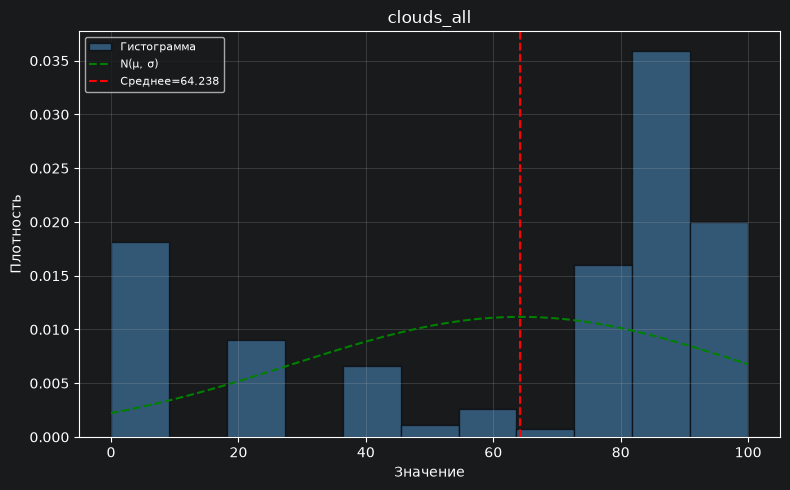

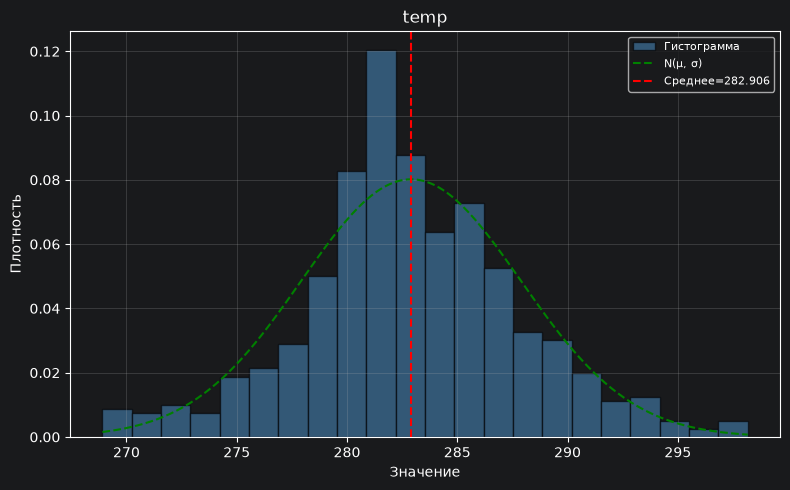

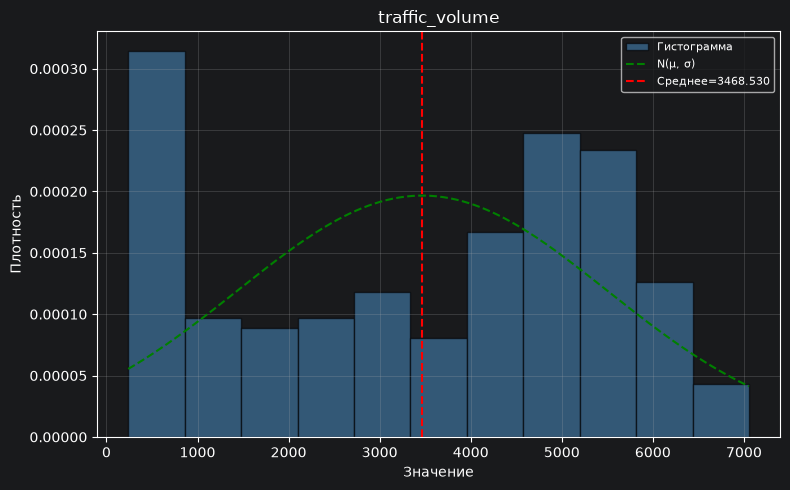

In [185]:
clouds_all   = df["clouds_all"]
temp      = df["temp"]
traffic   = df[TARGET]

def plot_distribution(values, title,bins="auto"):
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n == 0:
        print(f"[{title}] Нет данных")
        return None

    mean = np.mean(values)
    std = np.std(values, ddof=1) if n > 1 else 0.0

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    ax.hist(values, bins=bins, density=True, alpha=0.6,
            color="steelblue", edgecolor="black", label="Гистограмма")
    if n > 1 and std > 0:
        xs = np.linspace(values.min(), values.max(), 200)
        ax.plot(xs, stats.norm.pdf(xs, mean, std),
                color="green", ls="--", lw=1.5, label="N(μ, σ)")
    ax.axvline(mean,   color="red",    ls="--", lw=1.5, label=f"Среднее={mean:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Плотность")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_distribution(clouds_all,"clouds_all")
plot_distribution(temp,"temp")
plot_distribution(traffic,"traffic_volume")

# Распределения признаков

## Переменная `temp`

Значения эксцесса (0.57) и асимметричности (0.06) указывают на минимальное отклонение от нормального распределения; среднее, медиана и мода почти равны; график близок к графику нормального распределения. Распределение переменной `temp` можно назвать нормальным.

## Переменная `clouds_all`

Значения эксцесса (−1.60) и асимметричности (−0.34) говорят о некритичном отклонении от нормального распределения. Асимметрия слабая, а отрицательный эксцесс указывает на плосковершинность. На графике видны выбросы.

## Зависимая переменная `traffic_volume`

Значения эксцесса (−1.30) и асимметричности (−0.24) показывают некритичное отклонение от нормального распределения по форме. На графике видны выбросы. Первичный анализ показывает существенное различие между медианой и средним, что объясняется влиянием этих выбросов.

---

**Вывод:** данные не идеально нормальны, есть выбросы, но их немного и они отражают реальные особенности трафика (часы пик, периоды низкой нагрузки, погодные аномалии), поэтому выбросы **не удаляются** - иначе потеряется информация и сократится и без того небольшая выборка.

In [186]:
def add_time_features(df, date_col,unit=None, date_format=None,drop_original=True, inplace=False):
    if not inplace:
        df = df.copy()

    if date_col not in df.columns:
        raise ValueError(f"Столбец '{date_col}' не найден. "
                         f"Доступные: {list(df.columns)}")

    if unit is not None:
        dt = pd.to_datetime(df[date_col], unit=unit, errors="coerce")
    elif date_format is not None:
        dt = pd.to_datetime(df[date_col], format=date_format, errors="coerce")
    else:
        dt = pd.to_datetime(df[date_col], errors="coerce")

    n_bad = dt.isna().sum()
    if n_bad > 0:
        print(f"[add_time_features] Не удалось распарсить {n_bad} значений "
              f"({n_bad / len(dt) * 100:.2f}%).")

    # числовые компоненты
    df["year"]  = dt.dt.year
    df["month"] = dt.dt.month
    df["day"]   = dt.dt.day

    hour = dt.dt.hour

    def _part(h):
        if pd.isna(h):
            return "unknown"
        if 6 <= h < 12:
            return "morning"
        if 12 <= h < 18:
            return "day"
        if 18 <= h < 24:
            return "evening"
        return "night"

    df["part_of_day"] = hour.map(_part)

    if drop_original:
        df = df.drop(columns=[date_col])

    if inplace:
        return None
    return df

if "date_time" in df.columns:
    df = add_time_features(df, "date_time", unit=None, drop_original=True)

df.head()

cat_cols = [
    c for c in df.columns
    if c != TARGET
       and not pd.api.types.is_numeric_dtype(df[c])
       and df[c].notna().any()
]
original_cats = list(cat_cols)

if cat_cols:
    dummies = pd.get_dummies(
        df[cat_cols].astype(str),
        prefix=cat_cols,
        drop_first=True,
        dtype=int
    )
    df = df.drop(columns=original_cats)
    df = pd.concat([df, dummies], axis=1)

df = df.apply(pd.to_numeric, errors="coerce")

print("Итоговый размер после обработки данных:", df.shape)
df.head()

Итоговый размер после обработки данных: (600, 16)


,temp,clouds_all,traffic_volume,year,month,day,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Thunderstorm,part_of_day_evening,part_of_day_morning,part_of_day_night
0,288.28,40,5545,2012,10,2,1,0,0,0,0,0,0,0,1,0
1,289.36,75,4516,2012,10,2,1,0,0,0,0,0,0,0,1,0
2,289.58,90,4767,2012,10,2,1,0,0,0,0,0,0,0,1,0
3,290.13,90,5026,2012,10,2,1,0,0,0,0,0,0,0,0,0
4,291.14,75,4918,2012,10,2,1,0,0,0,0,0,0,0,0,0


## 2. Подготовка данных

Для дальнейшего анализа было проведено преобразование категориальных переменных:

### Переменная `holiday`

Переменная **`holiday`** удалена — первичный анализ показал сильный перевес в сторону одного значения.

### Переменная `weather_main`

Переменная **`weather_main`** была закодирована с помощью метода **One-Hot Encoding** и разбита на следующие бинарные признаки:

- `weather_main_Clouds`
- `weather_main_Drizzle`
- `weather_main_Fog`
- `weather_main_Haze`
- `weather_main_Mist`
- `weather_main_Rain`
- `weather_main_Thunderstorm`

### Переменная `date_time`

Переменная **`date_time`** была закодирована в 4 переменных:

- **День** был выделен в переменную `day`
- **Время суток** было разделено на 3 переменных:
  - `part_of_day_evening`
  - `part_of_day_morning`
  - `part_of_day_night`

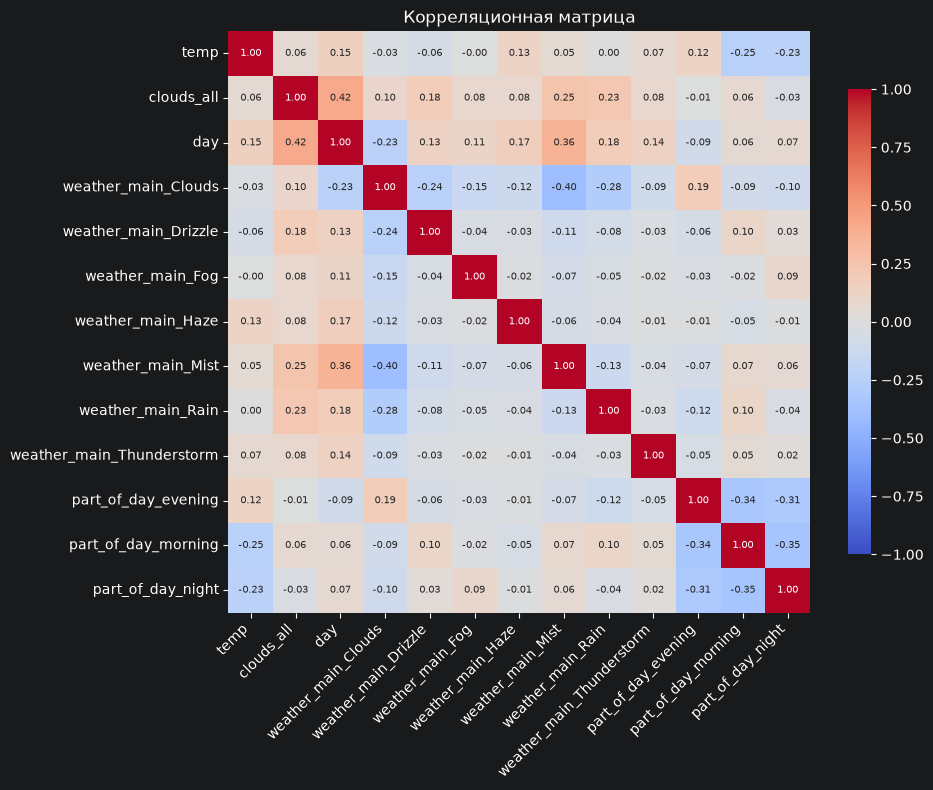

In [187]:
feature_cols = [c for c in df.columns if c != TARGET]
df_num = df[feature_cols].dropna(axis=1, how="all")
df_num = df_num.loc[:, df_num.std() > 0]

if df_num.shape[1] >= 2:
    corr_matrix = df_num.corr()

    plt.figure(figsize=(max(10, 0.6 * len(corr_matrix)),
                        max(8, 0.6 * len(corr_matrix))))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",
                fmt=".2f", vmin=-1, vmax=1, square=True,
                cbar_kws={"shrink": 0.8},
                annot_kws={"size": 7})
    plt.title("Корреляционная матрица")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 3. Корреляционный анализ и мультиколлинеарность
### Анализ корреляционной матрицы

Корреляционная матрица показывает, что сильной мультиколлинеарности между разнородными признаками нет: максимальная связь наблюдается между `clouds_all` и `day` (0.42), что ниже критического порога. Умеренные корреляции внутри One-Hot групп (`weather_main_*`, `part_of_day_*`) ожидаемы и обусловлены самой природой кодирования - взаимоисключающие категории дают отрицательные связи до −0.40. Признаки `temp` и части суток связаны слабо-умеренно (до −0.25), что отражает естественную суточную динамику температуры. Редкие погодные явления (`Drizzle`, `Fog`, `Haze`, `Thunderstorm`) практически не коррелируют с остальными признаками (|r| < 0.2). Для количественной оценки мультиколлинеарности целесообразно рассчитать VIF.

In [188]:
feature_cols = [c for c in df.columns if c != TARGET]
df_num = df[feature_cols].dropna(axis=1, how="all")
df_num = df_num.loc[:, df_num.std() > 0]
vif_data = {}
feature_names = df_num.columns.tolist()
for col in feature_names:
    X_others = df_num.drop(columns=[col]).values
    y = df_num[col].values
    model = LinearRegression().fit(X_others, y)
    r_squared = model.score(X_others, y)
    if r_squared >= 1.0 - 1e-12:
        vif = float("inf")
    else:
        vif = 1.0 / (1.0 - r_squared)
    vif_data[col] = vif
print(pd.Series(vif_data).sort_values(ascending=False))

weather_main_Clouds          3.507414
weather_main_Mist            3.378415
weather_main_Rain            2.444358
clouds_all                   2.374169
weather_main_Drizzle         2.086109
part_of_day_morning          1.891995
part_of_day_night            1.825135
day                          1.626256
part_of_day_evening          1.542721
weather_main_Fog             1.401547
weather_main_Haze            1.354029
temp                         1.332536
weather_main_Thunderstorm    1.249019
dtype: float64


Анализ коэффициентов VIF показал наличие мультиколлинеарности:  высокие значения зафиксированы у признаков `weather_main_Clouds` , `weather_main_Mist` (VIF > 3). Такие значения соответствуют умеренной мультиколлинеарности, при которой оценки коэффициентов линейной регрессии становятся менее устойчивыми, а стандартные ошибки — завышенными.


 Linear 
  Свободный член (β₀): 3460.7000
  Коэффициенты (β₁ … βₚ):
    temp                      +116.8153
    clouds_all                -49.8662
    day                       -87.0369
    weather_main_Clouds       +174.9357
    weather_main_Drizzle      -21.4061
    weather_main_Fog          -7.5803
    weather_main_Haze         -84.2408
    weather_main_Mist         -15.4077
    weather_main_Rain         +22.1656
    weather_main_Thunderstorm +0.0000
    part_of_day_evening       -1023.3987
    part_of_day_morning       -191.7370
    part_of_day_night         -1804.4645

 Lasso 
  Свободный член (β₀): 3460.7000
  Коэффициенты (β₁ … βₚ):
    temp                      +116.8161
    clouds_all                -49.8403
    day                       -87.0286
    weather_main_Clouds       +174.9041
    weather_main_Drizzle      -21.4188
    weather_main_Fog          -7.5809
    weather_main_Haze         -84.2339
    weather_main_Mist         -15.4242
    weather_main_Rain         +22.1355

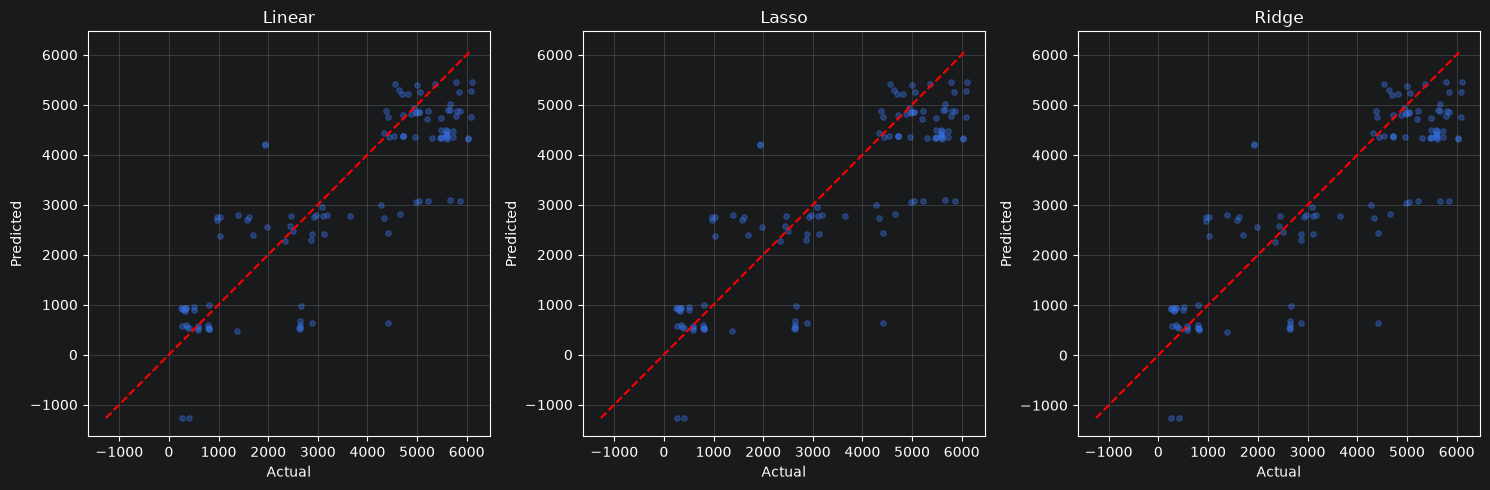

In [189]:
def build_linear_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())])


def build_lasso_model(alpha=0.01, max_iter=50000, tol=1e-3, random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=max_iter,
                        tol=tol, random_state=random_state))])


def build_ridge_model(alpha=1.0, random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha, random_state=random_state))])


def build_all_regression_models(alpha_lasso=0.01, alpha_ridge=1.0):
    return {
        "Linear": build_linear_model(),
        "Lasso":  build_lasso_model(alpha=alpha_lasso),
        "Ridge":  build_ridge_model(alpha=alpha_ridge),
    }


def fit_and_evaluate(model, X_train, y_train, X_test,
                     cv_folds=5):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    tscv = TimeSeriesSplit(n_splits=cv_folds)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv, scoring="neg_root_mean_squared_error"
    )

    return y_pred, -cv_scores.mean(), cv_scores.std()


def train_all_models(X, y, test_size=0.2, cv_folds=5,
                     alpha_lasso=0.01, alpha_ridge=1.0,
                     shuffle=False, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=shuffle,
        random_state=random_state
    )
    models = build_all_regression_models(
        alpha_lasso=alpha_lasso, alpha_ridge=alpha_ridge
    )

    trained, preds = {}, {}

    for name, model in models.items():
        y_pred, cv_rmse_mean, cv_rmse_std = fit_and_evaluate(
            model, X_train, y_train, X_test,
            cv_folds=cv_folds
        )
        trained[name] = model
        preds[name] = {
            "y_pred": y_pred,
            "cv_rmse_mean": cv_rmse_mean,
            "cv_rmse_std": cv_rmse_std,
        }

    return trained, preds, (X_train, X_test, y_train, y_test)


def plot_predicted_vs_actual(y_true, preds_dict):
    n = len(preds_dict)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    y_true = np.asarray(y_true, dtype=float)

    for ax, (name, item) in zip(axes, preds_dict.items()):
        y_pred = np.asarray(item["y_pred"], dtype=float)
        ax.scatter(y_true, y_pred, alpha=0.4, s=15)
        lims = [min(y_true.min(), y_pred.min()),
                max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", lw=1.5)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(name)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


X = df_num
y = pd.to_numeric(df[TARGET], errors="coerce")

mask = y.notna() & X.notna().all(axis=1)
X = X[mask]
y = y[mask]

models, preds, (X_train, X_test, y_train, y_test) = train_all_models(
    X, y, test_size=0.2, cv_folds=5,
    alpha_lasso=0.01, alpha_ridge=1.0,
    shuffle=False
)
for name, model in models.items():
    reg = model.named_steps["model"]
    print(f"\n {name} ")
    print(f"  Свободный член (β₀): {reg.intercept_:.4f}")
    print("  Коэффициенты (β₁ … βₚ):")
    for fname, coef in zip(feature_names, reg.coef_):
        print(f"    {fname:<25} {coef:+.4f}")

plot_predicted_vs_actual(y_test, preds)

## 4. Регрессионные модели до устранения мультиколлинеарности
Были построены и обучены три регрессионные модели — линейная (МНК), Lasso (L1-регуляризация) и Ridge (L2-регуляризация). Каждая оформлена в виде `Pipeline`, объединяющего стандартизацию признаков (`StandardScaler`) и сам регрессор: это гарантирует корректное масштабирование внутри кросс-валидации.

Данные разделены на тренировочную и тестовую выборки в пропорции 80/20.

In [190]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = float("nan")

    return {"RMSE": rmse, "R²": r2, "MAPE (%)": mape}

results = {}
for name, model in models.items():
    y_pred = preds[name]["y_pred"]
    metrics = regression_metrics(y_test, y_pred)

    metrics["CV RMSE (mean)"] = preds[name]["cv_rmse_mean"]
    metrics["CV RMSE (std)"]  = preds[name]["cv_rmse_std"]

    results[name] = metrics
    print(f"\n--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")



--- Linear ---
  RMSE: 1148.3422
  R²: 0.6773
  MAPE (%): 51.3610
  CV RMSE (mean): 1391.4453
  CV RMSE (std): 387.6392

--- Lasso ---
  RMSE: 1148.3015
  R²: 0.6774
  MAPE (%): 51.3599
  CV RMSE (mean): 1391.3847
  CV RMSE (std): 387.5843

--- Ridge ---
  RMSE: 1147.1323
  R²: 0.6780
  MAPE (%): 51.5458
  CV RMSE (mean): 1361.8129
  CV RMSE (std): 347.3986


Для каждой модели были рассчитаны метрики - RMSE (Root Mean Square Error), R² (коэффициент детерминации), MAPE (Mean Absolute Percentage Error),CV RMSE (mean) и CV RMSE (std) .

| Модель | RMSE | R² | MAPE (%) | CV RMSE (mean) | CV RMSE (std) |
| :---: | :---: | :---: | :---: | :---: | :---: |
| Linear | 1148.3422 | 0.6773 | 51.3610 | 1391.4453 | 387.6392 |
| Lasso | 1148.3015 | 0.6774 | 51.3599 | 1391.3847 | 387.5843 |
| Ridge | 1147.1323 | 0.6780 | 51.5458 | 1361.8129 | 347.3986 |

**Коэффициент детерминации** каждой модели близок к **0.67** — модель объясняет около 67% вариации зависимой переменной. Модели имеют умеренную объяснительную способность.

**MAPE = 51.4%** для всех моделей: в среднем модель ошибается на 51% от фактического значения трафика, , что говорит о низкой точности.

**RMSE ≈ 1148** - абсолютная ошибка модели сопоставима с половиной стандартного отклонения целевой переменной, что соответствует умеренной точности прогноза.

Построенные модели демонстрируют **умеренную объяснительную способность (R² ≈ 0.67)** и **низкую практическую точность (MAPE = 51.4%, RMSE ≈ 1148)**. Они **не подходят для точного прогнозирования**.

  Тест Бройша — Пагана:  LM = 55.24972364829051, p-value = 3.652876480225207e-07, α = 0.05
  Вывод: ГЕТЕРОСКЕДАСТИЧНОСТЬ (нулевая гипотеза отвергается)


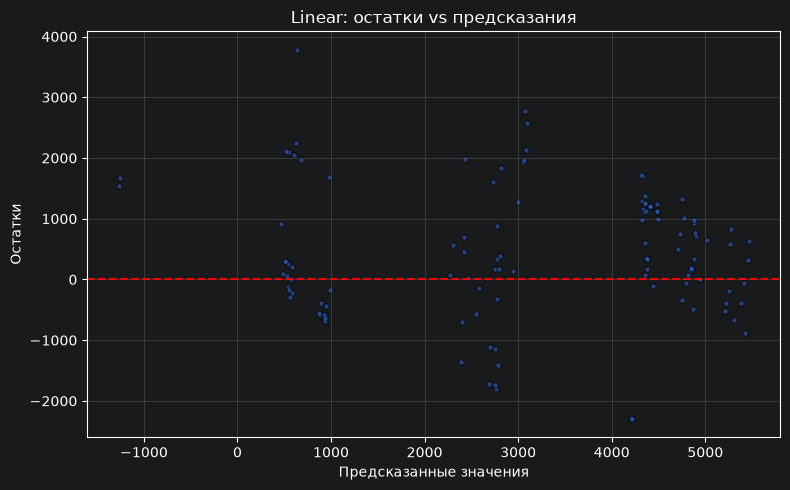

  Тест Бройша — Пагана:  LM = 55.2412150982839, p-value = 3.6654707142386405e-07, α = 0.05
  Вывод: ГЕТЕРОСКЕДАСТИЧНОСТЬ (нулевая гипотеза отвергается)


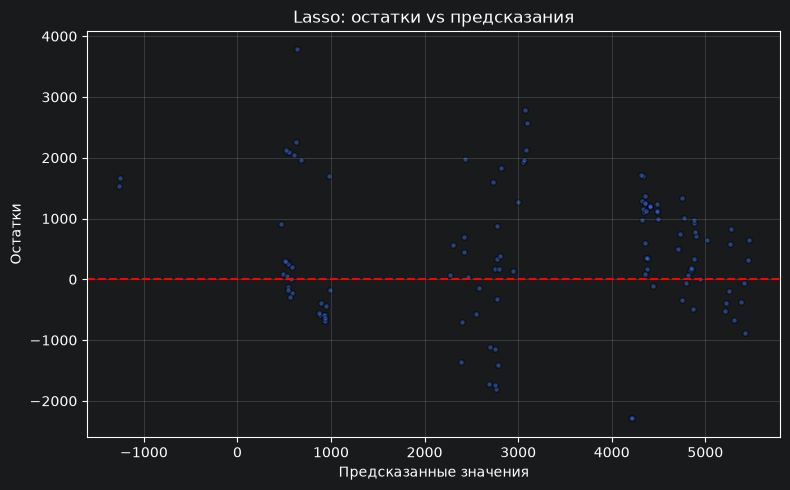

  Тест Бройша — Пагана:  LM = 55.33281593280257, p-value = 3.532114421883154e-07, α = 0.05
  Вывод: ГЕТЕРОСКЕДАСТИЧНОСТЬ (нулевая гипотеза отвергается)


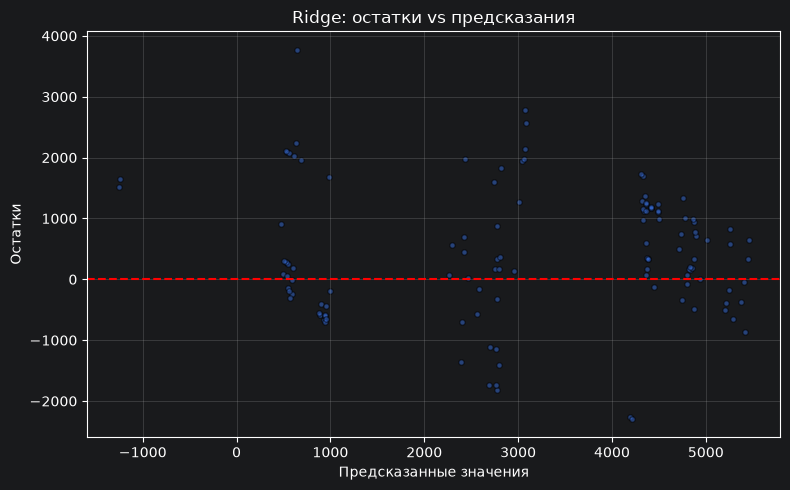

In [191]:
def plot_residuals_and_test(model, X_test, y_test, model_name="model",
                            alpha=0.05, figsize=(8, 5)):
    y_pred = model.predict(X_test)
    y_true = np.asarray(y_test, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    residuals = y_true - y_pred

    # Тест Бройша — Пагана на гетероскедастичность
    X_arr = np.asarray(X_test, dtype=float)
    X_arr = sm.add_constant(X_arr, has_constant="add")

    lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(residuals, X_arr)

    test_results = {
        "LM statistic": lm_stat,
        "LM p-value": lm_pvalue,
        "F statistic": f_stat,
        "F p-value": f_pvalue,
    }

    print(f"  Тест Бройша — Пагана:  LM = {lm_stat}, "
          f"p-value = {lm_pvalue}, α = {alpha}")

    if not np.isnan(lm_pvalue):
        if lm_pvalue < alpha:
            verdict = "ГЕТЕРОСКЕДАСТИЧНОСТЬ (нулевая гипотеза отвергается)"
        else:
            verdict = "ГОМОСКЕДАСТИЧНОСТЬ (нулевая гипотеза не отвергается)"
        print(f"  Вывод: {verdict}")

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.scatter(y_pred, residuals, alpha=0.5, s=15, edgecolor="k")
    ax.axhline(0, color="red", ls="--", lw=1.5)
    ax.set_xlabel("Предсказанные значения")
    ax.set_ylabel("Остатки")
    ax.set_title(f"{model_name}: остатки vs предсказания")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return residuals, test_results

for name, model in models.items():
    residuals, test_results = plot_residuals_and_test(
        model, X_test, y_test, model_name=name
    )

## 5. График остатков моделей и исследование структуры остатков на предмет гомоскедастичности или гетероскедастичности.
Для каждой из трёх моделей (Linear, Lasso, Ridge) был построен график остатков и проведён тест Бройша - Пагана на гетероскедастичность. Результаты представлены в таблице:

| Модель | LM statistic | LM p-value | F statistic | F p-value |
| :---: | :---: | :---: | :---: | :---: |
| Linear | 55.249724 | 0.0 | 6.957464 | 0.0 |
| Lasso | 55.241215 | 0.0 | 6.955479 | 0.0 |
| Ridge | 55.332816 | 0.0 | 6.976881 | 0.0 |

### Интерпретация

В остатках всех трёх моделей присутствует **гетероскедастичность** — дисперсия ошибок не постоянна, разброс точек вокруг линии регрессии не одинаков для всех наблюдений, а меняется в зависимости от значения независимой переменной или номера наблюдения.

Компонент для 95% дисперсии: 10


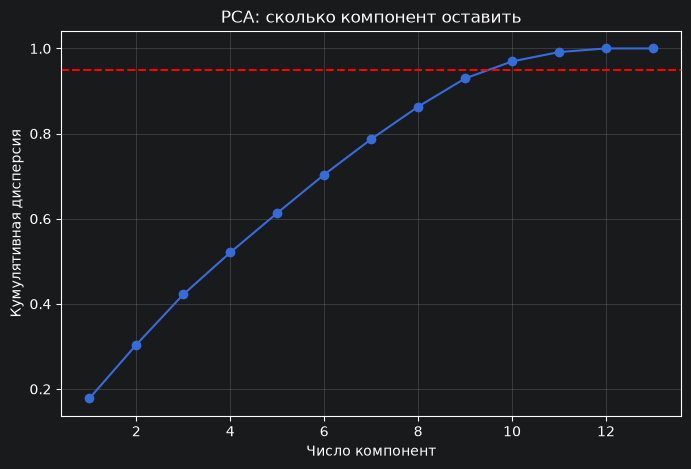

In [192]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_pipe = make_pipeline(PCA())
X_proj = pca_pipe.fit_transform(X_train_scaled)

pca = pca_pipe.named_steps["pca"]

n95 = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.95) + 1
print(f"Компонент для 95% дисперсии: {n95}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), "o-")
plt.axhline(0.95, color="red", ls="--")
plt.xlabel("Число компонент"); plt.ylabel("Кумулятивная дисперсия")
plt.title("PCA: сколько компонент оставить"); plt.grid(alpha=0.3); plt.show()

## 6. Использование метода главных компонент (PCA)
Для устранения мультиколлинеарности был применен метод главных компонент (PCA). Перед PCA признаки **стандартизованы** (среднее 0, дисперсия 1). Были найден 10 главных компонент максимальной дисперсии данных.

In [193]:
def _pca_preprocessor(n_components):
    return [
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_components)),]

def build_linear_model_pca(n_components=10):
    return Pipeline(_pca_preprocessor(n_components) + [
        ("model", LinearRegression())])

def build_lasso_model_pca(n_components=10, alpha=0.01,
                          max_iter=50000, tol=1e-3, random_state=42):
    return Pipeline(_pca_preprocessor(n_components) + [
        ("model", Lasso(alpha=alpha, max_iter=max_iter,
                        tol=tol, random_state=random_state))])

def build_ridge_model_pca(n_components=10, alpha=1.0, random_state=42):
    return Pipeline(_pca_preprocessor(n_components) + [
        ("model", Ridge(alpha=alpha, random_state=random_state))])

def build_all_regression_models_pca(n_components=10,
                                    alpha_lasso=0.01, alpha_ridge=1.0):
    return {
        "Linear+PCA": build_linear_model_pca(n_components),
        "Lasso+PCA":  build_lasso_model_pca(n_components, alpha=alpha_lasso),
        "Ridge+PCA":  build_ridge_model_pca(n_components, alpha=alpha_ridge),
    }

models_PCA = build_all_regression_models_pca(n_components=10)

all_results = {}

for name, model in models_PCA.items():
    y_pred, cv_rmse_mean, cv_rmse_std = fit_and_evaluate(
        model, X_train, y_train, X_test,
        cv_folds=5
    )
    metrics = regression_metrics(y_test, y_pred)
    metrics["CV RMSE (mean)"] = cv_rmse_mean
    metrics["CV RMSE (std)"]  = cv_rmse_std
    all_results[f"{name} [PCA]"] = metrics

for name, model in models_PCA.items():
    reg = model.named_steps["model"]
    n_comp = model.named_steps["pca"].n_components_
    pc_names = [f"PC{i+1}" for i in range(n_comp)]
    print(f"\n {name} ")
    print(f"  Свободный член (β₀): {reg.intercept_:.4f}")
    print("  Коэффициенты (β₁ … βₚ):")
    for pc, coef in zip(pc_names, reg.coef_):
        print(f"    {pc:<25} {coef:+.4f}")
    print("\n")
print(pd.DataFrame(all_results).T.round(4))


 Linear+PCA 
  Свободный член (β₀): 3460.7000
  Коэффициенты (β₁ … βₚ):
    PC1                       -133.4427
    PC2                       -785.7831
    PC3                       +719.5703
    PC4                       -325.6835
    PC5                       -58.7612
    PC6                       -92.7919
    PC7                       -93.1318
    PC8                       +482.9175
    PC9                       +610.0020
    PC10                      +174.5036



 Lasso+PCA 
  Свободный член (β₀): 3460.7000
  Коэффициенты (β₁ … βₚ):
    PC1                       -133.4380
    PC2                       -785.7765
    PC3                       +719.5632
    PC4                       -325.6750
    PC5                       -58.7523
    PC6                       -92.7827
    PC7                       -93.1218
    PC8                       +482.9065
    PC9                       +609.9895
    PC10                      +174.4827



 Ridge+PCA 
  Свободный член (β₀): 3460.7000
  Коэффицие

Результат применения метода главных компонент (PCA).

|   Модель   | RMSE | R² | MAPE (%) | CV RMSE (mean) | CV RMSE (std) |
|:----------:| :---: | :---: | :---: | :---: | :---: |
| Linear+PCA | 1382.1891 | 0.5325 | 89.6113 | 1567.4085 | 277.0887 |
| Lasso+PCA  | 1382.1496 | 0.5326 | 89.6096 | 1567.3775 | 277.0688 |
| Ridge+PCA  | 1381.3297 | 0.5331 | 89.6139 | 1536.7938 | 239.7130 |

Применение PCA  ухудшило качество моделей: R² снизился с 0.68 до 0.53, MAPE вырос с 52% до 90%, RMSE - с 1140 до 1382. Это объясняется тем, что исходная мультиколлинеарность была умеренной, а сжатие размерности привело к потере информации. Метод главных компонент нецелесообразен для данной задачи.

## Заключение

1. **Мультиколлинеарность** в исходных данных умеренная: значения VIF у `weather_main_Clouds`, `weather_main_Mist`  превышают 3; у остальных признаков VIF ниже 3.

2. **Модели до PCA** (линейная, Lasso, Ridge) дают R² ≈ 0.68, RMSE ≈ 1148, MAPE ≈ 51.4%. Регуляризация не дала заметного эффекта: Lasso с α = 0.01 почти не обнулил коэффициенты, Ridge не изменил структуру модели.

3. **Анализ остатков**, проведённый с помощью теста Бройша - Пагана, выявил **гетероскедастичность** у всех трёх построенных моделей.

4. **PCA**, сжал данные до **10 компонент**. Применение PCA **ухудшило** качество моделей: R² снизился с 0.677–0.678 до 0.532–0.533, MAPE вырос с ~51% до ~90%, RMSE увеличился с 1147–1148 до 1381–1382, CV RMSE (mean) вырос с 1361–1391 до 1537–1567. Единственное улучшение - снижение CV RMSE (std) с 347–391 до 240–277 - объясняется упрощением модели, но достигнуто ценой общей потери точности.
